<a href="https://colab.research.google.com/github/KofiSmith/Machine-learning-/blob/main/Health%20Cost%20Prediction/fcc_predict_health_costs_with_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import libraries. You may or may not use all of these.
!pip install -q git+https://github.com/tensorflow/docs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

try:
  # %tensorflow_version only exists in Colab.
  %tensorflow_version 2.x
except Exception:
  pass
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras.callbacks import EarlyStopping

import tensorflow_docs as tfdocs
import tensorflow_docs.plots
import tensorflow_docs.modeling

  Preparing metadata (setup.py) ... done
Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


In [ ]:
# Import data
!wget https://cdn.freecodecamp.org/project-data/health-costs/insurance.csv
dataset = pd.read_csv('insurance.csv')
dataset

--2024-12-20 14:52:53--  https://cdn.freecodecamp.org/project-data/health-costs/insurance.csv
Resolving cdn.freecodecamp.org (cdn.freecodecamp.org)... 104.26.3.33, 172.67.70.149, 104.26.2.33, ...
Connecting to cdn.freecodecamp.org (cdn.freecodecamp.org)|104.26.3.33|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 50264 (49K) [text/csv]
Saving to: ‘insurance.csv’

insurance.csv       100%[===================>]  49.09K  --.-KB/s    in 0.002s  

2024-12-20 14:52:54 (28.3 MB/s) - ‘insurance.csv’ saved [50264/50264]



,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,male,31.0,3,no,northwest,10600.55
1334,18,female,31.9,0,no,northeast,2205.98
1335,18,female,36.9,0,no,southeast,1629.83
1336,21,female,25.8,0,no,southwest,2007.95


In [ ]:
# Generate dummies for sex
dataset = pd.concat([dataset,pd.get_dummies(dataset['sex'],prefix="sex")],axis=1)
dataset.drop('sex', axis=1, inplace=True)

# Grenerate dummies for smoker
dataset = pd.concat([dataset,pd.get_dummies(dataset['smoker'],prefix="smoker")],axis=1)
dataset.drop('smoker', axis=1, inplace=True)

# Generate dummies for region
dataset = pd.concat([dataset,pd.get_dummies(dataset['region'],prefix="region")],axis=1)
dataset.drop('region', axis=1, inplace=True)
dataset

,age,bmi,children,expenses,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.9,0,16884.92,True,False,False,True,False,False,False,True
1,18,33.8,1,1725.55,False,True,True,False,False,False,True,False
2,28,33.0,3,4449.46,False,True,True,False,False,False,True,False
3,33,22.7,0,21984.47,False,True,True,False,False,True,False,False
4,32,28.9,0,3866.86,False,True,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,31.0,3,10600.55,False,True,True,False,False,True,False,False
1334,18,31.9,0,2205.98,True,False,True,False,True,False,False,False
1335,18,36.9,0,1629.83,True,False,True,False,False,False,True,False
1336,21,25.8,0,2007.95,True,False,True,False,False,False,False,True


In [ ]:
x_columns = dataset.columns.drop('expenses')
x = dataset[x_columns].values
y = dataset['expenses'].values

In [ ]:
import numpy as np

# Get the number of samples and features from the shape of x
num_samples = x.shape[0]  # Number of rows in x
num_features = x.shape[1]  # Number of columns in x

# Reshape your arrays using the derived values
x = x.reshape(num_samples, num_features)

# Assuming y represents target values and should have shape (num_samples, 1)
y = y.reshape(num_samples, 1)

In [ ]:
train_dataset, test_dataset, train_labels, test_labels = train_test_split(x, y, train_size=0.8)

In [ ]:
train_labels = train_labels.reshape(train_dataset.shape[0], 1)  # Reshape train_labels
test_labels = test_labels.reshape(test_dataset.shape[0], 1)  # Reshape test_labels

In [ ]:
from sklearn.preprocessing import StandardScaler

# Select numerical features
numerical_features = ['age', 'bmi', 'children']

# Create a scaler object
scaler = StandardScaler()

# Fit the scaler on the training data and transform
train_dataset[:, :3] = scaler.fit_transform(train_dataset[:, :3])

# Transform the test data using the trained scaler
test_dataset[:, :3] = scaler.transform(test_dataset[:, :3])

In [ ]:
import numpy as np

# Reshape your arrays
x = x.reshape(num_samples, num_features)
y = y.reshape(num_samples, 1)

In [51]:
# Build the neural network
train_dataset = np.array(train_dataset,dtype=np.float32)
test_dataset = np.array(test_dataset, dtype=np.float32)

#train_dataset = train_dataset.as_numpy_iterator()
#test_dataset = test_dataset.as_numpy_iterator()

model = Sequential()
model.add(Dense(50, input_dim=train_dataset.shape[1], activation='relu'))
model.add(Dense(25, activation='relu'))
model.add(Dense(1))
model.compile(loss='mean_absolute_error', metrics=["mean_absolute_error", "mean_squared_error"], optimizer='adam')
monitor = EarlyStopping(monitor='val_loss', min_delta=1e-3, patience=10, verbose=1, mode='auto', restore_best_weights=True)
model.fit(train_dataset, train_labels, validation_data=(test_dataset, test_labels), callbacks=[monitor], verbose=2, epochs=10000)

Epoch 1/10000


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


34/34 - 2s - 53ms/step - loss: 13201.0635 - mean_absolute_error: 13201.0635 - mean_squared_error: 317105376.0000 - val_loss: 13546.1484 - val_mean_absolute_error: 13546.1484 - val_mean_squared_error: 344736416.0000
Epoch 2/10000
34/34 - 0s - 9ms/step - loss: 13199.6172 - mean_absolute_error: 13199.6172 - mean_squared_error: 317068832.0000 - val_loss: 13544.1562 - val_mean_absolute_error: 13544.1562 - val_mean_squared_error: 344682528.0000
Epoch 3/10000
34/34 - 0s - 4ms/step - loss: 13196.2812 - mean_absolute_error: 13196.2812 - mean_squared_error: 316980224.0000 - val_loss: 13538.6455 - val_mean_absolute_error: 13538.6455 - val_mean_squared_error: 344532320.0000
Epoch 4/10000
34/34 - 0s - 4ms/step - loss: 13187.7344 - mean_absolute_error: 13187.7344 - mean_squared_error: 316753920.0000 - val_loss: 13525.8516 - val_mean_absolute_error: 13525.8516 - val_mean_squared_error: 344186048.0000
Epoch 5/10000
34/34 - 0s - 3ms/step - loss: 13169.5908 - mean_absolute_error: 13169.5908 - mean_squar

9/9 - 0s - 3ms/step - loss: 1187.4775 - mean_absolute_error: 1187.4775 - mean_squared_error: 15444964.0000
Testing set Mean Abs Error: 1187.48 expenses
 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


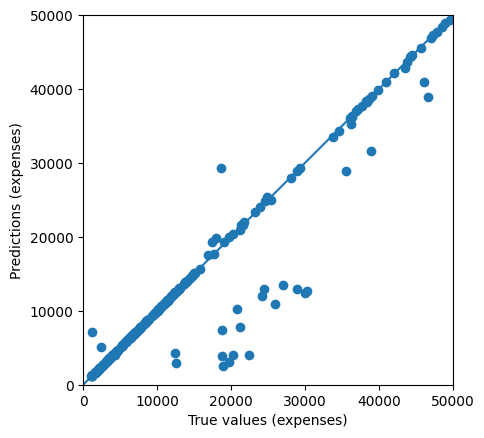

In [52]:
# RUN THIS CELL TO TEST YOUR MODEL. DO NOT MODIFY CONTENTS.
# Test model by checking how well the model generalizes using the test set.
loss, mae, mse = model.evaluate(test_dataset, test_labels, verbose=2)

print("Testing set Mean Abs Error: {:5.2f} expenses".format(mae))

if mae < 3500:
  print(" ")
else:
  print("The Mean Abs Error must be less than 3500. Keep trying.")

# Plot predictions.
test_predictions = model.predict(test_dataset).flatten()

a = plt.axes(aspect='equal')
plt.scatter(test_labels, test_predictions)
plt.xlabel('True values (expenses)')
plt.ylabel('Predictions (expenses)')
lims = [0, 50000]
plt.xlim(lims)
plt.ylim(lims)
_ = plt.plot(lims,lims)